# Analysis of Conmplexity

In [4]:
import pathlib as pth


base_location = pth.Path.cwd().parent / "data"

In [ ]:
import pandas as pd

ground_truth_metrics_location = base_location.as_posix() + "/ground_truth_metrics.csv"
llama_metrics_location = base_location.as_posix()  + "/llama_metrics.csv"
gemma_metrics_location = base_location.as_posix()  + "/gemma_metrics.csv"

ground_truth_metrics = pd.read_csv(ground_truth_metrics_location)
llama_metrics = pd.read_csv(llama_metrics_location)
gemma_metrics = pd.read_csv(gemma_metrics_location)

ground_truth_metrics["Level"] = ground_truth_metrics["fname"].apply(
    lambda x: int(x.split("_")[1]) if "level_" in x else 0
)
key_metrics = ["N_word", "ASL", "TTR_word", "FRE_GL", "SMOG"]
complexity_summary = ground_truth_metrics.groupby("Level")[key_metrics].mean()

llama_metrics['Type'] = llama_metrics['fname'].apply(
    lambda x: 'Few-Shot' if x.startswith('f_') else 'Zero-Shot'
)
llama_metrics['Level'] = llama_metrics['fname'].str.extract(r'_(\d)').astype(int)
few_shot = llama_metrics[llama_metrics['Type'] == 'Few-Shot']
zero_shot = llama_metrics[llama_metrics['Type'] == 'Zero-Shot']
few_shot_summary = few_shot.groupby('Level')[key_metrics].mean()
zero_shot_summary = zero_shot.groupby('Level')[key_metrics].mean()

gemma_metrics['Type'] = gemma_metrics['fname'].apply(
    lambda x: 'Few-Shot' if x.startswith('f_') else 'Zero-Shot'
)
gemma_metrics['Level'] = gemma_metrics['fname'].str.extract(r'_(\d)').astype(int)
few_shot_gemma = gemma_metrics[gemma_metrics['Type'] == 'Few-Shot']
zero_shot_gemma = gemma_metrics[gemma_metrics['Type'] == 'Zero-Shot']
few_shot_gemma_summary = few_shot_gemma.groupby('Level')[key_metrics].mean()
zero_shot_gemma_summary = zero_shot_gemma.groupby('Level')[key_metrics].mean()

combined_table = pd.concat(
    [
        complexity_summary.reset_index().assign(Source="Ground Truth"),
        few_shot_summary.reset_index().assign(Source="LLaMA Few-Shot"),
        zero_shot_summary.reset_index().assign(Source="LLaMA Zero-Shot"),
        few_shot_gemma_summary.reset_index().assign(Source="Gemma Few-Shot"),
        zero_shot_gemma_summary.reset_index().assign(Source="Gemma Zero-Shot"),
    ]
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(combined_table)

   Level  N_word        ASL  TTR_word     FRE_GL       SMOG           Source
0      0  2929.0  14.645000  0.611471  13.789311  17.732308     Ground Truth
1      1  2078.0   8.345382  0.599134   9.231006  11.869233     Ground Truth
2      2  1767.0   6.221831  0.608942   7.287299   9.493267     Ground Truth
3      3  1527.0   5.532609  0.616241   6.880823   8.794526     Ground Truth
0      1  1989.0   9.994975  0.618401  10.523626  13.579301   LLaMA Few-Shot
1      2  1585.0   8.005051  0.622082   9.388677  12.037456   LLaMA Few-Shot
2      3  1117.0   5.670051  0.651746   7.556932   9.307692   LLaMA Few-Shot
0      1  2039.0  10.195000  0.629720  10.727902  13.874466  LLaMA Zero-Shot
1      2  1821.0   9.105000  0.640308   9.591166  12.459151  LLaMA Zero-Shot
2      3  1075.0   5.375000  0.695814   7.280942   9.592714  LLaMA Zero-Shot
0      1  2763.0   9.397959  0.550851   9.283572  12.414291   Gemma Few-Shot
1      2  2173.0   6.665644  0.582145   7.550277  10.274531   Gemma Few-Shot

# Human Written Simplifications

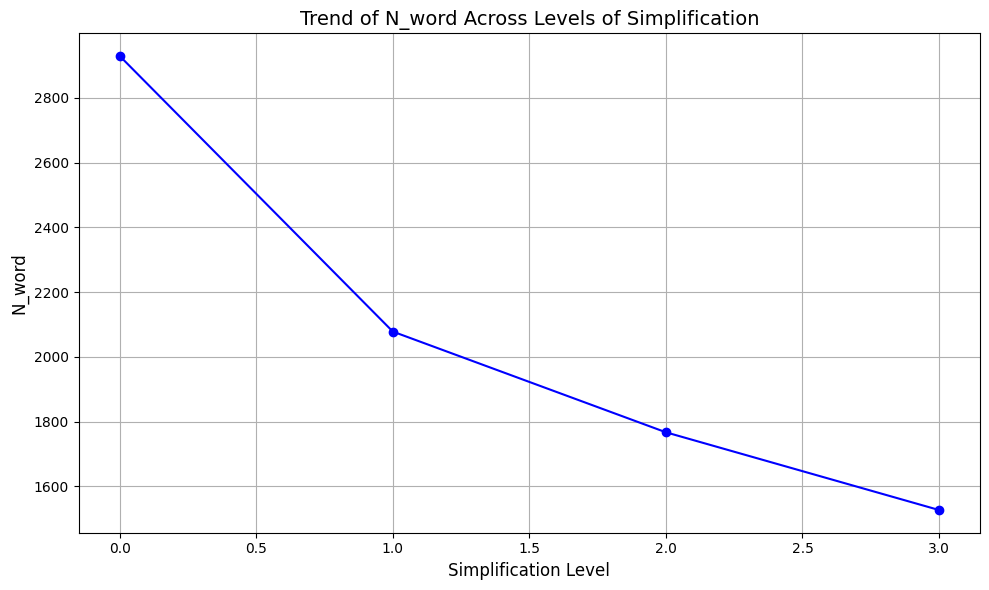

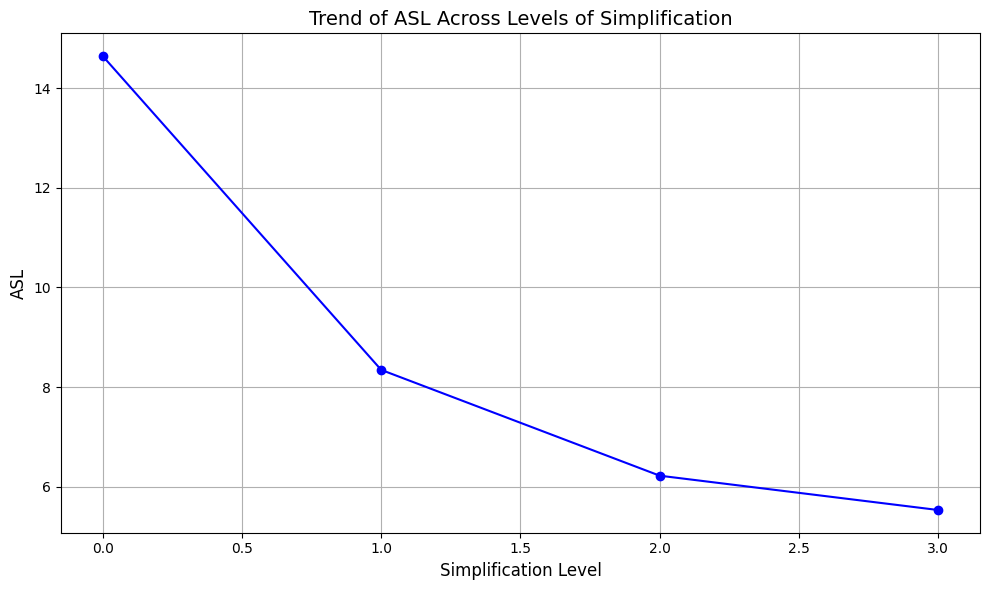

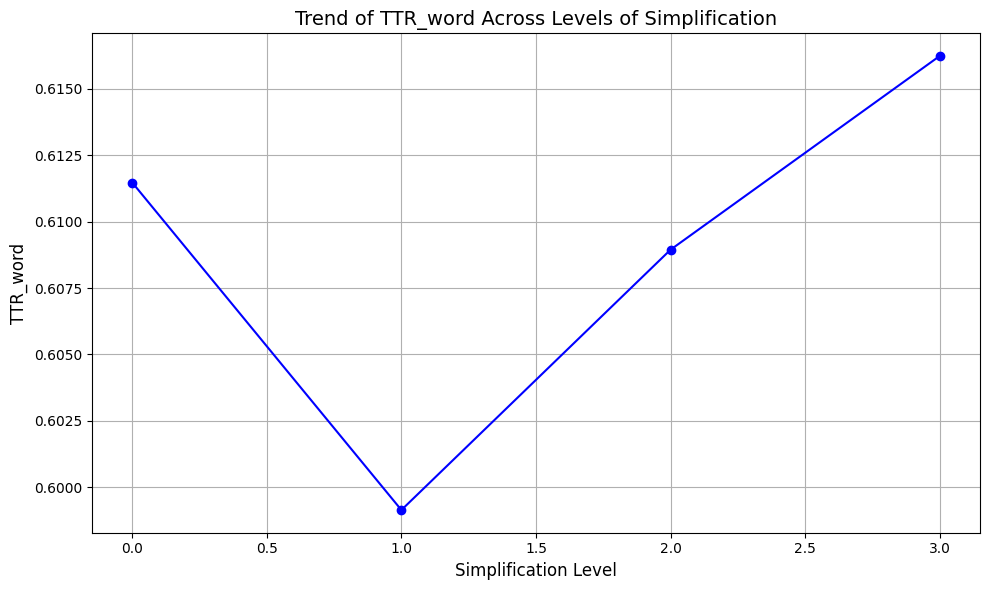

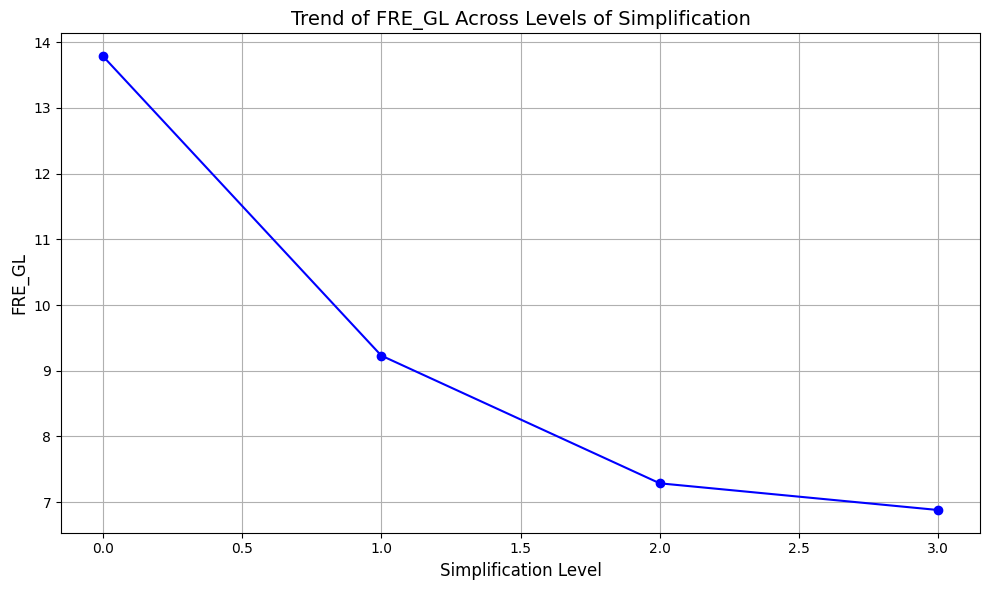

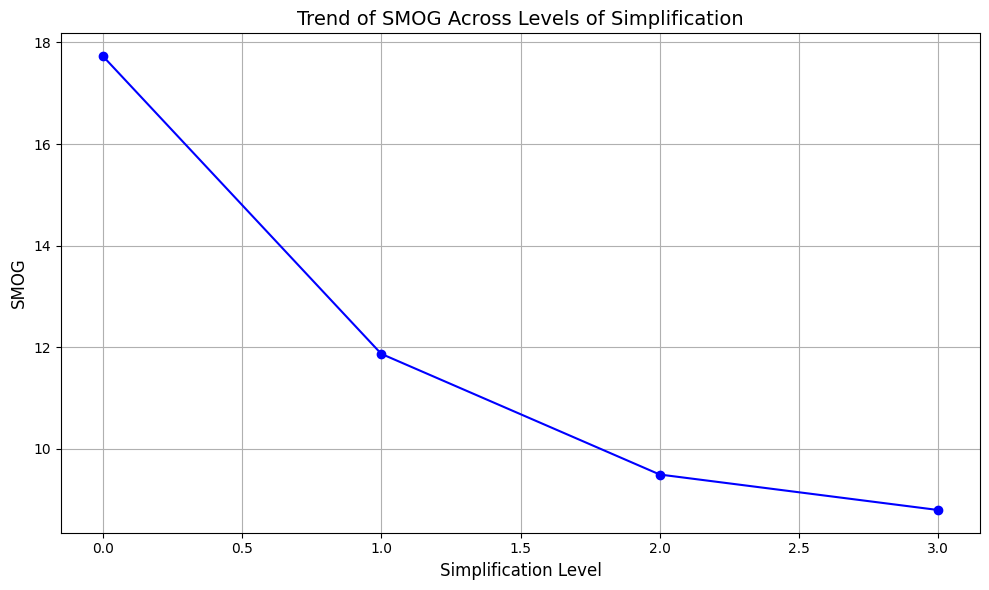

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


ground_truth_metrics_location = base_location / "data" / "ground_truth_metrics.csv"
ground_truth_metrics = pd.read_csv(ground_truth_metrics_location)


ground_truth_metrics["Level"] = ground_truth_metrics["fname"].apply(
    lambda x: int(x.split("_")[1]) if "level_" in x else 0
)


key_metrics = ["N_word", "ASL", "TTR_word", "FRE_GL", "SMOG"]


complexity_summary = ground_truth_metrics.groupby("Level")[key_metrics].mean()


for metric in key_metrics:
    plt.figure(figsize=(10, 6))
    plt.plot(complexity_summary.index, complexity_summary[metric], marker="o", linestyle="-", color="b")
    plt.title(f"Trend of {metric} Across Levels of Simplification", fontsize=14)
    plt.xlabel("Simplification Level", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Llama

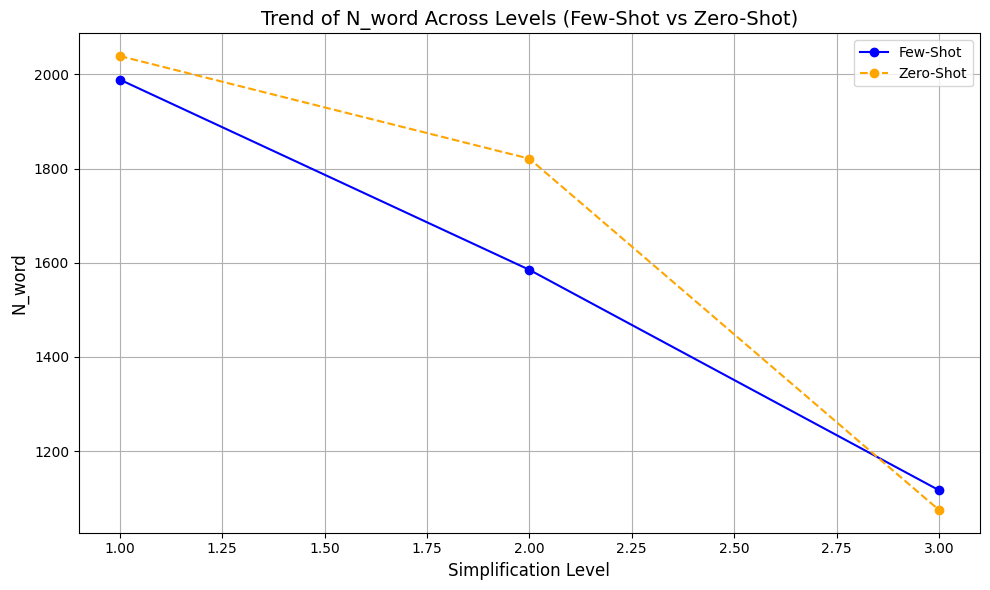

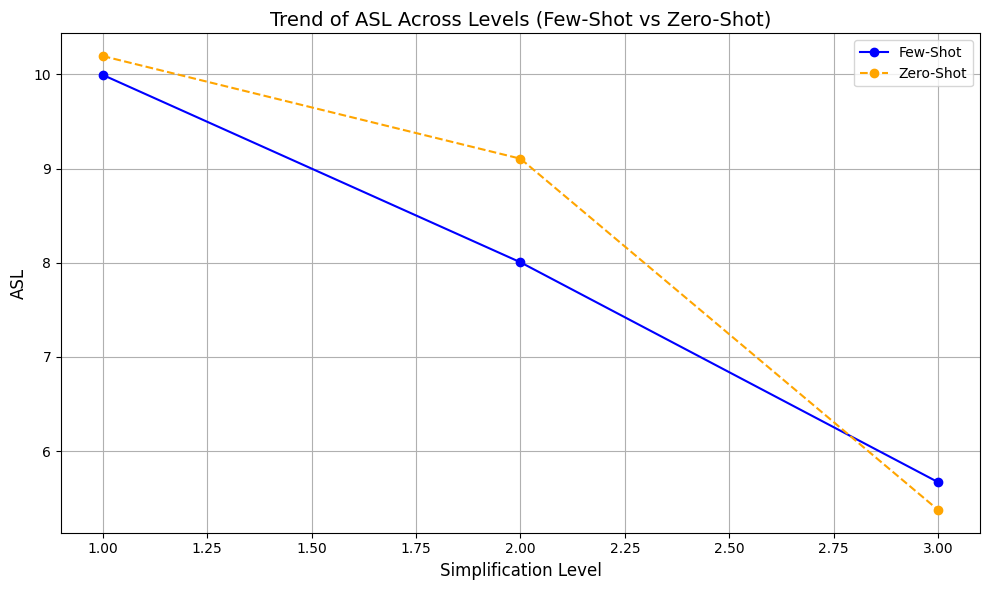

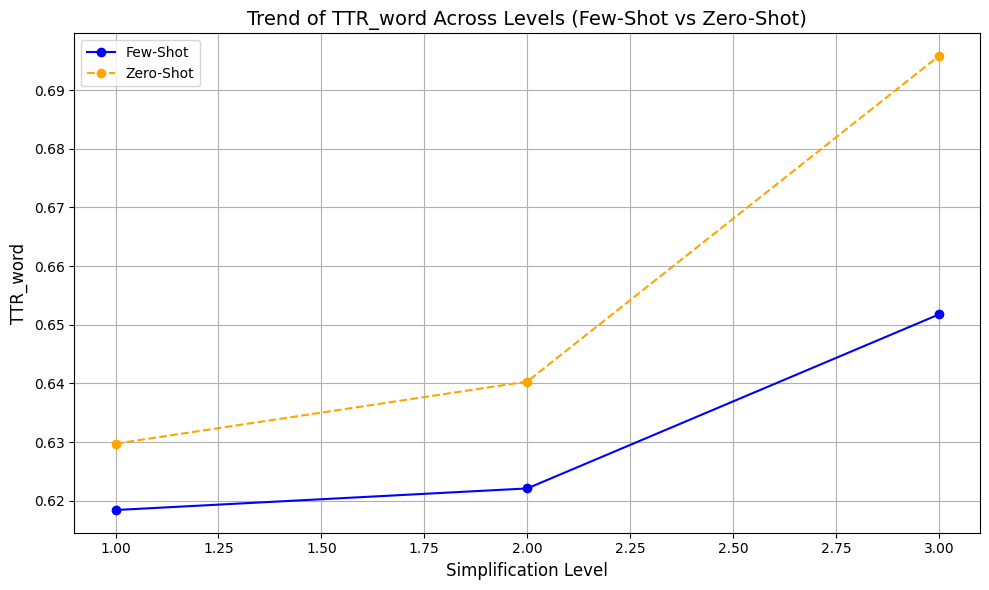

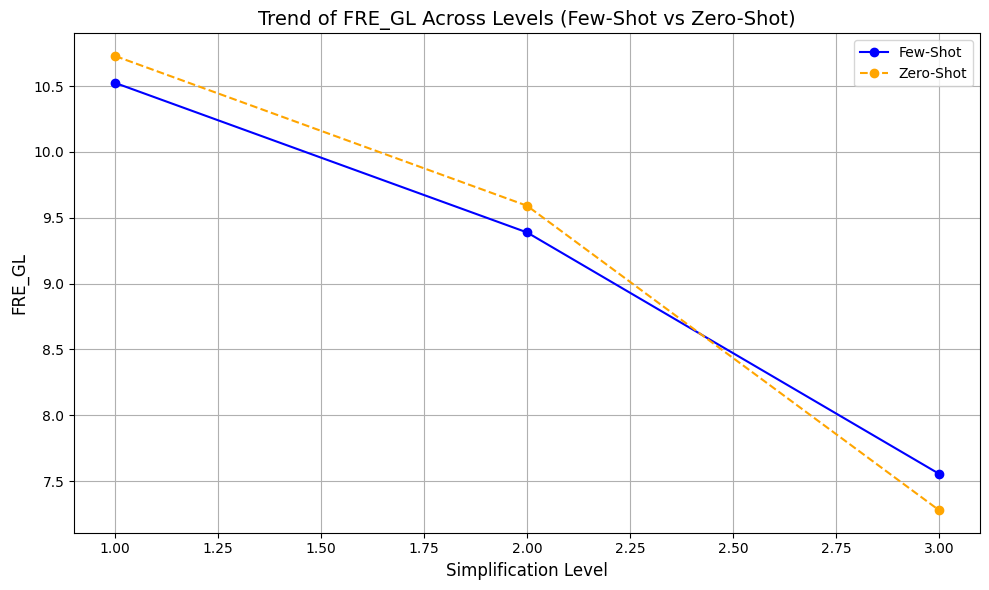

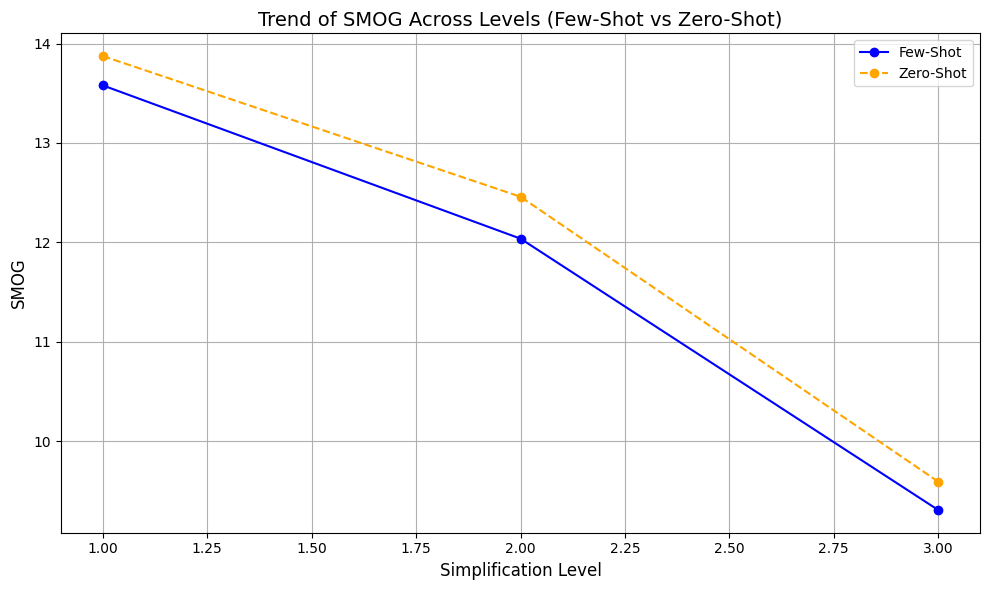

In [ ]:
llama_metrics_location = base_location / "data" / "llama_metrics.csv"
llama_metrics = pd.read_csv(llama_metrics_location)


llama_metrics['Type'] = llama_metrics['fname'].apply(
    lambda x: 'Few-Shot' if x.startswith('f_') else 'Zero-Shot'
)


llama_metrics['Level'] = llama_metrics['fname'].str.extract(r'_(\d)').astype(int)


key_metrics = ['N_word', 'ASL', 'TTR_word', 'FRE_GL', 'SMOG']


few_shot = llama_metrics[llama_metrics['Type'] == 'Few-Shot']
zero_shot = llama_metrics[llama_metrics['Type'] == 'Zero-Shot']


few_shot_summary = few_shot.groupby('Level')[key_metrics].mean()
zero_shot_summary = zero_shot.groupby('Level')[key_metrics].mean()


for metric in key_metrics:
    plt.figure(figsize=(10, 6))
    plt.plot(few_shot_summary.index, few_shot_summary[metric], marker='o', linestyle='-', label='Few-Shot', color='blue')
    plt.plot(zero_shot_summary.index, zero_shot_summary[metric], marker='o', linestyle='--', label='Zero-Shot', color='orange')
    plt.title(f"Trend of {metric} Across Levels (Few-Shot vs Zero-Shot)", fontsize=14)
    plt.xlabel("Simplification Level", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Gemma

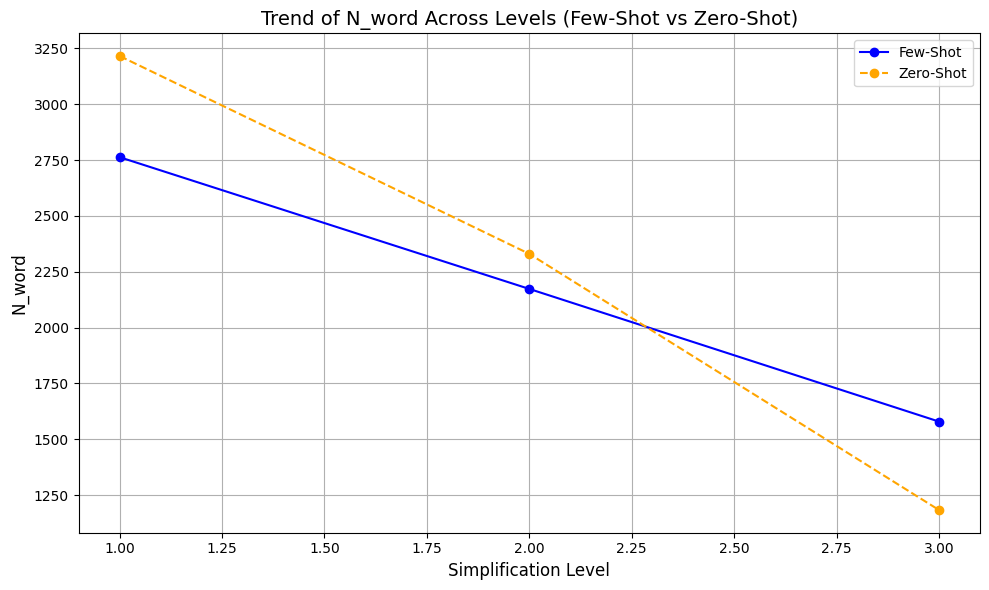

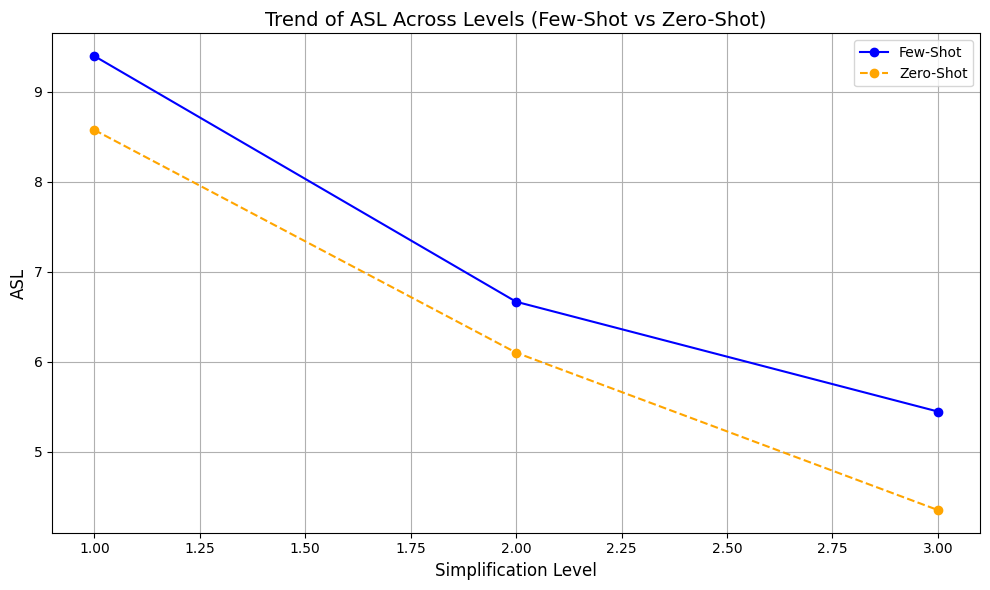

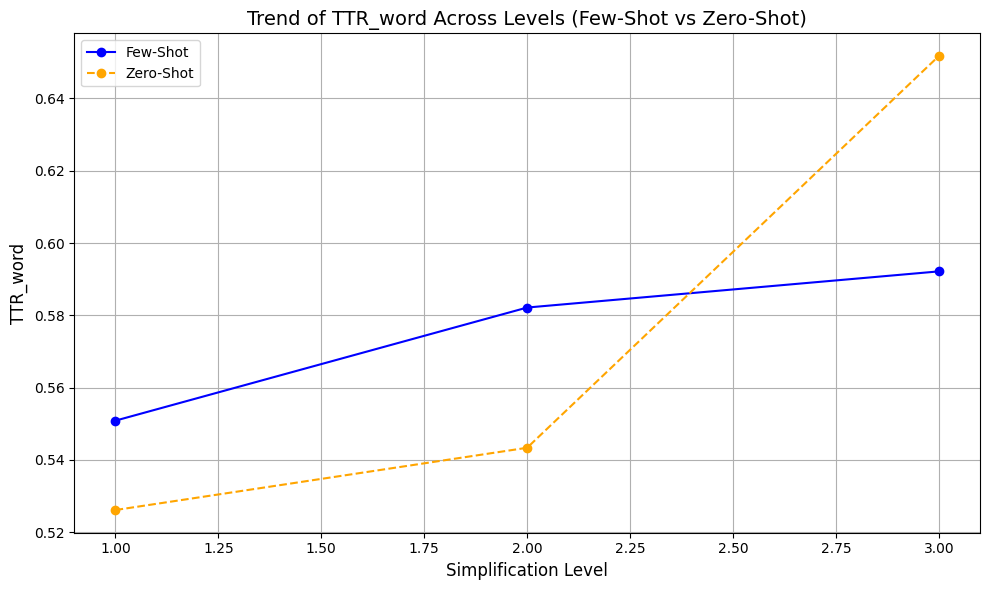

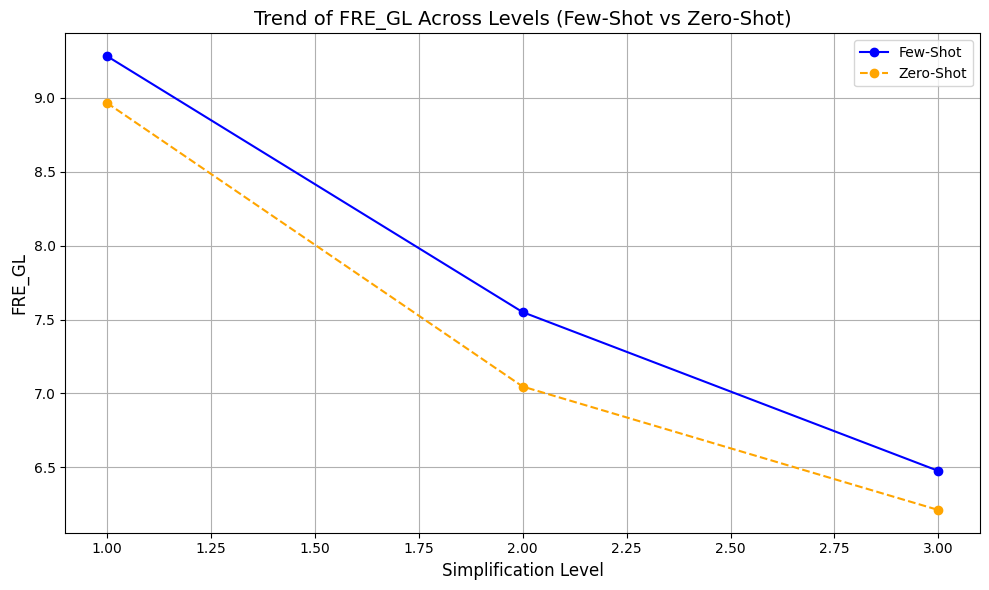

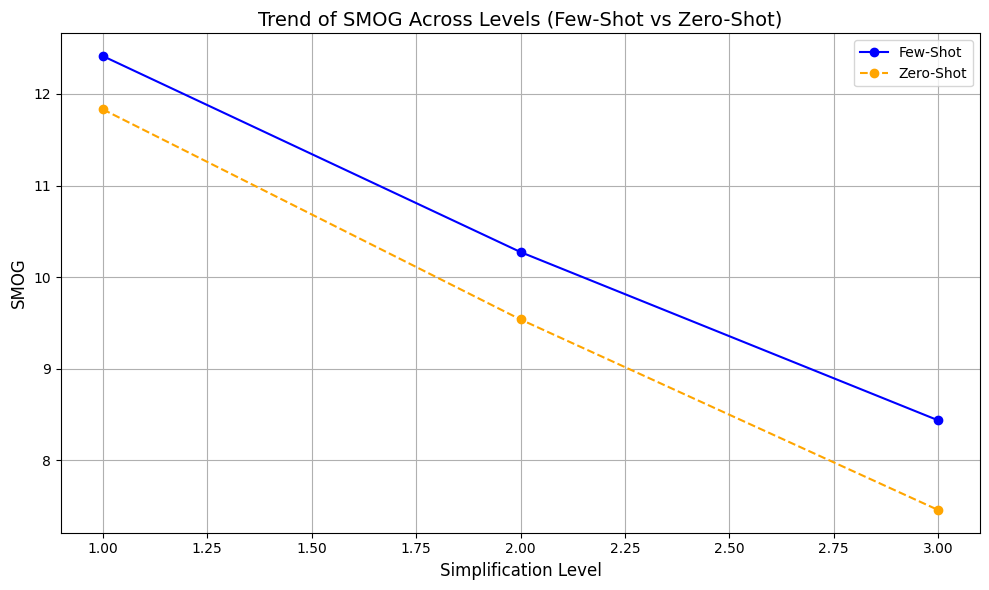

In [16]:
gemma_metrics_location = base_location / "data" / "gemma_metrics.csv"
gemma_metrics = pd.read_csv(gemma_metrics_location)


gemma_metrics['Type'] = gemma_metrics['fname'].apply(
    lambda x: 'Few-Shot' if x.startswith('f_') else 'Zero-Shot'
)


gemma_metrics['Level'] = gemma_metrics['fname'].str.extract(r'_(\d)').astype(int)


key_metrics = ['N_word', 'ASL', 'TTR_word', 'FRE_GL', 'SMOG']


few_shot = gemma_metrics[gemma_metrics['Type'] == 'Few-Shot']
zero_shot = gemma_metrics[gemma_metrics['Type'] == 'Zero-Shot']


few_shot_summary = few_shot.groupby('Level')[key_metrics].mean()
zero_shot_summary = zero_shot.groupby('Level')[key_metrics].mean()


for metric in key_metrics:
    plt.figure(figsize=(10, 6))
    plt.plot(few_shot_summary.index, few_shot_summary[metric], marker='o', linestyle='-', label='Few-Shot', color='blue')
    plt.plot(zero_shot_summary.index, zero_shot_summary[metric], marker='o', linestyle='--', label='Zero-Shot', color='orange')
    plt.title(f"Trend of {metric} Across Levels (Few-Shot vs Zero-Shot)", fontsize=14)
    plt.xlabel("Simplification Level", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
